# Between-Subjects Aggregation
Loads per-subject results saved by each analysis notebook and averages across participants.

In [2]:
from pathlib import Path
import numpy as np

PROJECT_ROOT    = Path('..').resolve()
DERIVATIVES_DIR = PROJECT_ROOT / 'data' / 'derivatives' / 'mne_preproc'
TASK            = 'Cannonball MF'

SUBJECTS = ['01', '02', '03', '04', '05']
SESSION  = '01'

def load_subject(subject):
    d      = DERIVATIVES_DIR / f'sub-{subject}' / f'ses-{SESSION}'
    prefix = f'sub-{subject}_ses-{SESSION}_task-{TASK}'

    files = {
        'main'     : d / f'{prefix}_results.npz',
        'rw_alpha' : d / f'{prefix}_rw_alpha_results.npz',
        'rw_beta'  : d / f'{prefix}_rw_beta_results.npz',
        'tgm'      : d / f'{prefix}_tgm_results.npz',
    }

    missing = [k for k, p in files.items() if not p.exists()]
    if missing:
        print(f'sub-{subject}: skipping — missing {missing}')
        return None

    return {k: np.load(str(p), allow_pickle=True) for k, p in files.items()}

data = {sub: load_subject(sub) for sub in SUBJECTS}
data = {sub: d for sub, d in data.items() if d is not None}
print(f'Loaded {len(data)} subject(s): {list(data.keys())}')

Loaded 5 subject(s): ['01', '02', '03', '04', '05']


Alpha — group mean=-25.068  SD=0.628  range=[-27.08, -21.89]
  sub-01: mean=-25.044  SD=0.635  n=713
  sub-02: mean=-24.973  SD=0.562  n=718
  sub-03: mean=-25.049  SD=0.641  n=720
  sub-04: mean=-25.136  SD=0.641  n=719
  sub-05: mean=-25.136  SD=0.641  n=719
Beta — group mean=-25.909  SD=0.502  range=[-27.36, -21.51]
  sub-01: mean=-26.200  SD=0.315  n=713
  sub-02: mean=-25.510  SD=0.247  n=718
  sub-03: mean=-25.641  SD=0.291  n=720
  sub-04: mean=-26.098  SD=0.561  n=719
  sub-05: mean=-26.098  SD=0.561  n=719


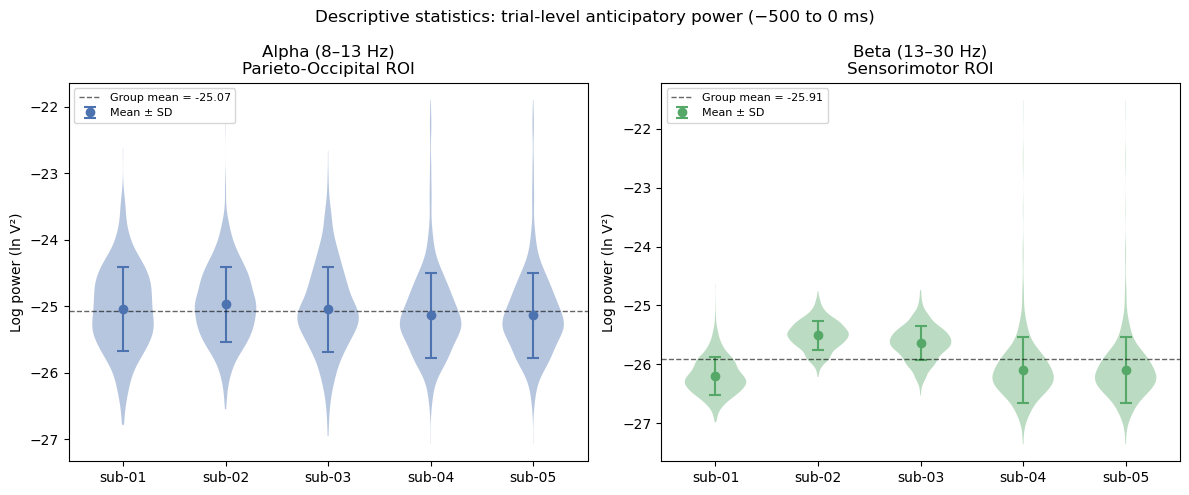

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Load trial-level power for all subjects ---
power_data = {}
for sub in SUBJECTS:
    d      = DERIVATIVES_DIR / f'sub-{sub}' / f'ses-{SESSION}'
    prefix = f'sub-{sub}_ses-{SESSION}_task-{TASK}'
    f      = d / f'{prefix}_alpha_beta_power.npz'
    if f.exists():
        m = np.load(str(f), allow_pickle=True)
        power_data[sub] = {
            'alpha' : np.log(m['alpha_power'].astype(float)),   # log-transform V²
            'beta'  : np.log(m['beta_power'].astype(float)),
        }

subs   = list(power_data.keys())
x      = np.arange(len(subs))
colors = {'alpha': '#4C72B0', 'beta': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, band, label in zip(axes, ['alpha', 'beta'], ['Alpha (8–13 Hz)\nParieto-Occipital ROI',
                                                      'Beta (13–30 Hz)\nSensorimotor ROI']):
    vals = [power_data[s][band] for s in subs]

    # Violin
    vp = ax.violinplot(vals, positions=x, widths=0.6, showmedians=False, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(colors[band])
        body.set_alpha(0.4)

    # Mean ± SD per subject
    means = np.array([v.mean() for v in vals])
    sds   = np.array([v.std()  for v in vals])
    ax.errorbar(x, means, yerr=sds, fmt='o', color=colors[band],
                capsize=4, capthick=1.5, linewidth=1.5, markersize=6, label='Mean ± SD')

    # Group mean line
    gm = np.concatenate(vals).mean()
    ax.axhline(gm, color='k', linestyle='--', linewidth=1, alpha=0.6, label=f'Group mean = {gm:.2f}')

    ax.set_xticks(x)
    ax.set_xticklabels([f'sub-{s}' for s in subs])
    ax.set_ylabel('Log power (ln V²)')
    ax.set_title(label)
    ax.legend(fontsize=8)

    # Print stats
    all_vals = np.concatenate(vals)
    print(f'{band.capitalize()} — group mean={all_vals.mean():.3f}  SD={all_vals.std():.3f}  '
          f'range=[{all_vals.min():.2f}, {all_vals.max():.2f}]')
    for s, m, sd in zip(subs, means, sds):
        print(f'  sub-{s}: mean={m:.3f}  SD={sd:.3f}  n={len(power_data[s][band])}')

fig.suptitle('Descriptive statistics: trial-level anticipatory power (−500 to 0 ms)', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# --- Alpha / Beta correlations with V(t) and |PE| ---
rows = []
for sub, d in data.items():
    m = d['main']
    rows.append({
        'subject'    : sub,
        'r_alpha_V'  : float(m['r_alpha_V']),
        'p_alpha_V'  : float(m['p_alpha_V']),
        'r_beta_V'   : float(m['r_beta_V']),
        'p_beta_V'   : float(m['p_beta_V']),
        'r_alpha_PE' : float(m['r_alpha_PE']),
        'p_alpha_PE' : float(m['p_alpha_PE']),
        'r_beta_PE'  : float(m['r_beta_PE']),
        'p_beta_PE'  : float(m['p_beta_PE']),
    })

corr_df = pd.DataFrame(rows).set_index('subject')
print('=== Correlation summary ===')
print(corr_df.to_string())

if len(SUBJECTS) > 1:
    print('\n=== Group means ===')
    print(corr_df.mean().to_string())

=== Correlation summary ===
         r_alpha_V  p_alpha_V  r_beta_V  p_beta_V  r_alpha_PE  p_alpha_PE  r_beta_PE  p_beta_PE
subject                                                                                        
01        0.045454   0.225427 -0.025339  0.499347   -0.067778    0.070493   0.006338   0.865842
02        0.041461   0.267208  0.014283  0.702405   -0.045327    0.225107  -0.004962   0.894402
03        0.056656   0.128807  0.051714  0.165702   -0.058367    0.117638  -0.038631   0.300589
04       -0.033874   0.364419  0.003012  0.935752   -0.011026    0.768042   0.045223   0.226173
05       -0.044443   0.233964 -0.000489  0.989553    0.017457    0.640515   0.006067   0.871080

=== Group means ===
r_alpha_V     0.013051
p_alpha_V     0.243965
r_beta_V      0.008636
p_beta_V      0.658552
r_alpha_PE   -0.033008
p_alpha_PE    0.364359
r_beta_PE     0.002807
p_beta_PE     0.631618


In [20]:
# --- RW model fit: best learning rate and peak r ---
rw_rows = []
for sub, d in data.items():
    ra = d['rw_alpha']
    rb = d['rw_beta']
    rw_rows.append({
        'subject'        : sub,
        'alpha_best_lr'  : float(ra['best_alpha']),
        'alpha_best_r'   : float(ra['best_r']),
        'alpha_best_p'   : float(ra['best_p']),
        'beta_best_lr'   : float(rb['best_alpha']),
        'beta_best_r'    : float(rb['best_r']),
        'beta_best_p'    : float(rb['best_p']),
    })

rw_df = pd.DataFrame(rw_rows).set_index('subject')
print('=== RW model fit summary ===')
print(rw_df.to_string())

=== RW model fit summary ===
         alpha_best_lr  alpha_best_r  alpha_best_p  beta_best_lr  beta_best_r  beta_best_p
subject                                                                                   
01                0.01     -0.070027      0.061823          0.99     0.064602     0.085848
02                0.55      0.087989      0.018611          0.01    -0.099318     0.007783
03                0.01     -0.094819      0.011077          0.04    -0.127185     0.000641
04                0.02     -0.078483      0.037216          0.01    -0.060996     0.105126
05                0.03     -0.083727      0.024963          0.99     0.124836     0.000957


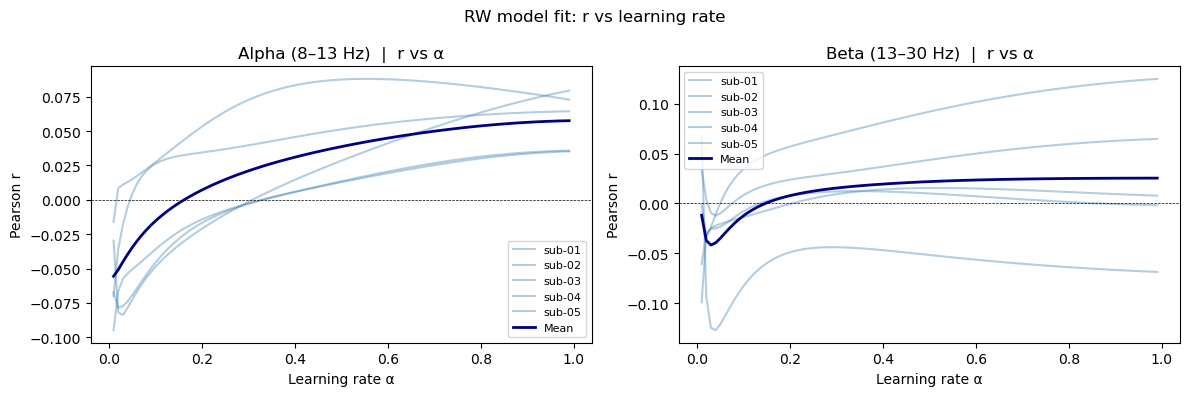

In [21]:
import matplotlib.pyplot as plt

# --- Group-averaged r vs alpha curves ---
alpha_grid = data[SUBJECTS[0]]['rw_alpha']['alpha_grid']

alpha_curves = np.stack([data[s]['rw_alpha']['r_curve'] for s in SUBJECTS])
beta_curves  = np.stack([data[s]['rw_beta']['r_curve']  for s in SUBJECTS])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, curves, label in zip(axes, [alpha_curves, beta_curves], ['Alpha (8–13 Hz)', 'Beta (13–30 Hz)']):
    for i, s in enumerate(SUBJECTS):
        ax.plot(alpha_grid, curves[i], alpha=0.4, color='steelblue', label=f'sub-{s}')
    if len(SUBJECTS) > 1:
        ax.plot(alpha_grid, curves.mean(axis=0), color='navy', linewidth=2, label='Mean')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Learning rate α')
    ax.set_ylabel('Pearson r')
    ax.set_title(f'{label}  |  r vs α')
    ax.legend(fontsize=8)

fig.suptitle('RW model fit: r vs learning rate')
plt.tight_layout()
plt.show()

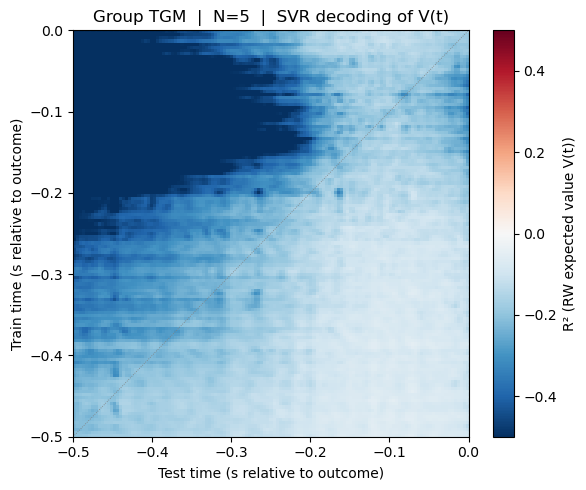

In [24]:
import matplotlib.pyplot as plt

# --- Group-averaged TGM ---
tgm_stack = np.stack([data[s]['tgm']['scores_mean'] for s in data])  # (n_subjects, n_train, n_test)
tgm_mean  = tgm_stack.mean(axis=0)
times     = data[next(iter(data))]['tgm']['times']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    tgm_mean,
    origin='lower',
    extent=[times[0], times[-1], times[0], times[-1]],
    aspect='auto',
    vmin=-0.5, vmax=0.5,
    cmap='RdBu_r'
)
fig.colorbar(im, ax=ax, label='R² (RW expected value V(t))')
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.plot(times, times, color='gray', linewidth=0.6, linestyle=':')
ax.set_xlabel('Test time (s relative to outcome)')
ax.set_ylabel('Train time (s relative to outcome)')
ax.set_title(f'Group TGM  |  N={len(data)}  |  SVR decoding of V(t)')
plt.tight_layout()
plt.show()

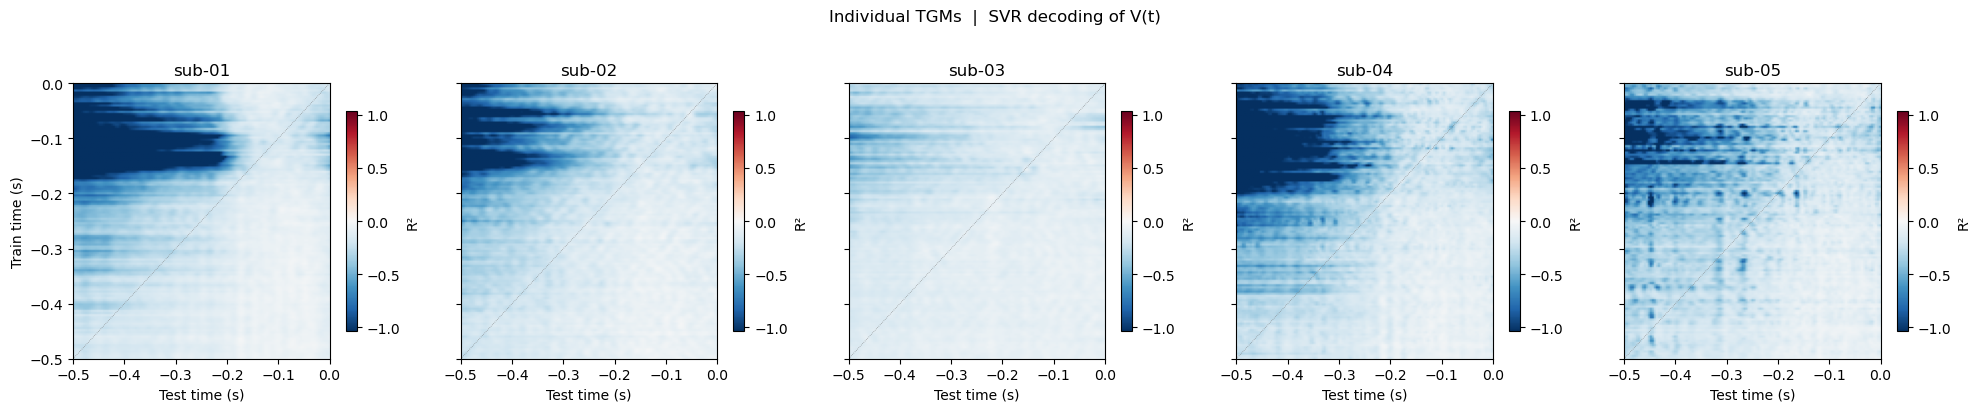

In [15]:
# --- Individual subject TGMs ---
subs  = list(data.keys())
times = data[subs[0]]['tgm']['times']
n     = len(subs)

all_scores = np.stack([data[s]['tgm']['scores_mean'] for s in subs])
vabs = np.percentile(np.abs(all_scores), 95)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, sub in zip(axes, subs):
    scores = data[sub]['tgm']['scores_mean']
    im = ax.imshow(
        scores,
        origin='lower',
        extent=[times[0], times[-1], times[0], times[-1]],
        aspect='auto',
        vmin=-vabs, vmax=vabs,
        cmap='RdBu_r'
    )
    ax.axhline(0, color='k', linestyle='--', linewidth=0.6, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.6, alpha=0.5)
    ax.plot(times, times, color='gray', linewidth=0.5, linestyle=':')
    ax.set_title(f'sub-{sub}')
    ax.set_xlabel('Test time (s)')
    fig.colorbar(im, ax=ax, label='R²', shrink=0.8)

axes[0].set_ylabel('Train time (s)')
fig.suptitle('Individual TGMs  |  SVR decoding of V(t)', y=1.02)
plt.tight_layout()
plt.show()

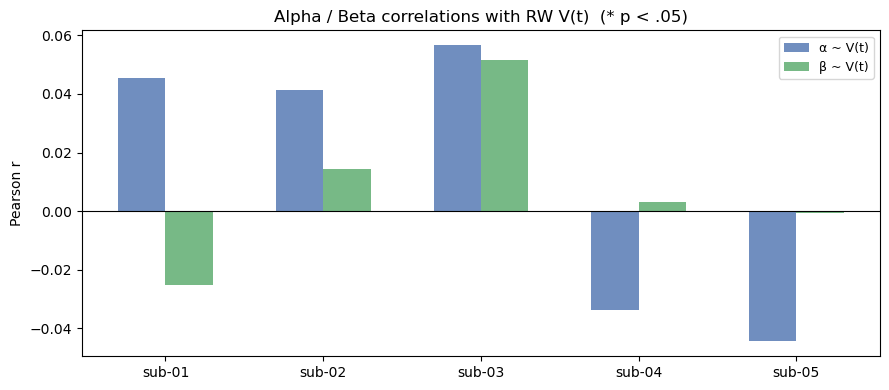

In [22]:
# --- V(t) correlation bar chart per subject ---
metrics = {
    'α ~ V(t)' : ('r_alpha_V', 'p_alpha_V'),
    'β ~ V(t)' : ('r_beta_V',  'p_beta_V'),
}

subs_main = list(corr_df.index)
x = np.arange(len(subs_main))
width = 0.3
colors = ['#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, (r_col, p_col)) in enumerate(metrics.items()):
    r_vals = corr_df[r_col].values
    p_vals = corr_df[p_col].values
    offset = (i - len(metrics) / 2 + 0.5) * width
    ax.bar(x + offset, r_vals, width, label=label, color=colors[i], alpha=0.8)
    for j, (r, p) in enumerate(zip(r_vals, p_vals)):
        if p < 0.05:
            ax.text(x[j] + offset, r + (0.003 if r >= 0 else -0.008),
                    '*', ha='center', va='bottom', fontsize=12)

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'sub-{s}' for s in subs_main])
ax.set_ylabel('Pearson r')
ax.set_title('Alpha / Beta correlations with RW V(t)  (* p < .05)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

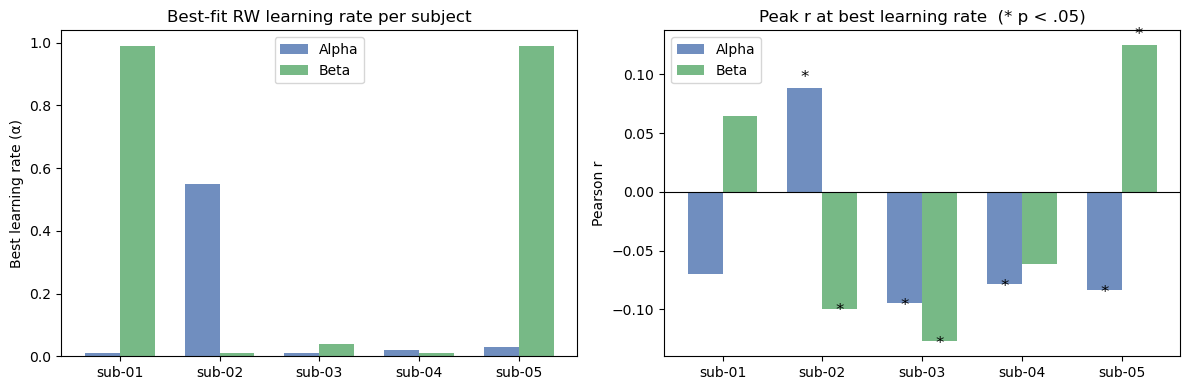

In [23]:
# --- Best learning rate & peak r per subject ---
subs_rw = list(rw_df.index)
x = np.arange(len(subs_rw))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: best learning rate
ax = axes[0]
ax.bar(x - width/2, rw_df['alpha_best_lr'], width, label='Alpha', color='#4C72B0', alpha=0.8)
ax.bar(x + width/2, rw_df['beta_best_lr'],  width, label='Beta',  color='#55A868', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'sub-{s}' for s in subs_rw])
ax.set_ylabel('Best learning rate (α)')
ax.set_title('Best-fit RW learning rate per subject')
ax.legend()

# Right: peak r at best learning rate (* if p < .05)
ax = axes[1]
ax.bar(x - width/2, rw_df['alpha_best_r'], width, label='Alpha', color='#4C72B0', alpha=0.8)
ax.bar(x + width/2, rw_df['beta_best_r'],  width, label='Beta',  color='#55A868', alpha=0.8)
for j, sub in enumerate(subs_rw):
    for r_col, p_col, offset in [('alpha_best_r', 'alpha_best_p', -width/2),
                                  ('beta_best_r',  'beta_best_p',  width/2)]:
        r, p = rw_df.loc[sub, r_col], rw_df.loc[sub, p_col]
        if p < 0.05:
            ax.text(x[j] + offset, r + (0.003 if r >= 0 else -0.008),
                    '*', ha='center', va='bottom', fontsize=12)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'sub-{s}' for s in subs_rw])
ax.set_ylabel('Pearson r')
ax.set_title('Peak r at best learning rate  (* p < .05)')
ax.legend()

plt.tight_layout()
plt.show()